In [67]:
from dspl_generator import DSPLGenerator

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [68]:
amp = 5.0

dspl = DSPLGenerator(
    fov=15,

    lens_img=None,
    source1_img=None,
    source2_img=None,

    lens_amp=4*amp,
    source1_amp=amp,
    source2_amp=amp,

    telescope="euclid",
    exposure_time=600
)

In [161]:
dspl.shuffle()
gamma = dspl.mass_kwargs[0][0]['gamma'] 

Find old critical curves and caustics

In [162]:
mu_wrts1, mu_wrts2 = dspl.get_magnification()

cc_wrts1_old, cc_wrts2_old = dspl.get_critical_curves()

caustic_wrts1_old, caustic_wrts2_old = dspl.get_caustics()

New cc and caustics

In [ ]:
init_guess_1 = [cc_wrts1_old[i][np.random.randint(len(cc_wrts1_old[i]))] for i in range(len(cc_wrts1_old))]
if len(init_guess_1) < 2:
    init_guess_1 += [[1e-3, 1e-3]]   

cc_wrts1_new, stop = dspl._critical_curves_polar(
    init_guess=init_guess_1, 
    plane=1,
    N=100_000,
    delta = 1e-3,
    )
print(stop)

init_guess_2 = [cc_wrts2_old[i][np.random.randint(len(cc_wrts2_old[i]))] for i in range(len(cc_wrts2_old))]
cc_wrts2_new, stop = dspl._critical_curves_polar(
    init_guess=init_guess_2, 
    plane=2,
    N=100_000
    delta=1e-3
    )
print(stop)

caustics_wrts1_x, caustics_wrts1_y = dspl._map(cc_wrts1_new,1)
caustics_wrts2_x, caustics_wrts2_y = dspl._map(cc_wrts2_new,2)

[[2 2]
 [2 2]]


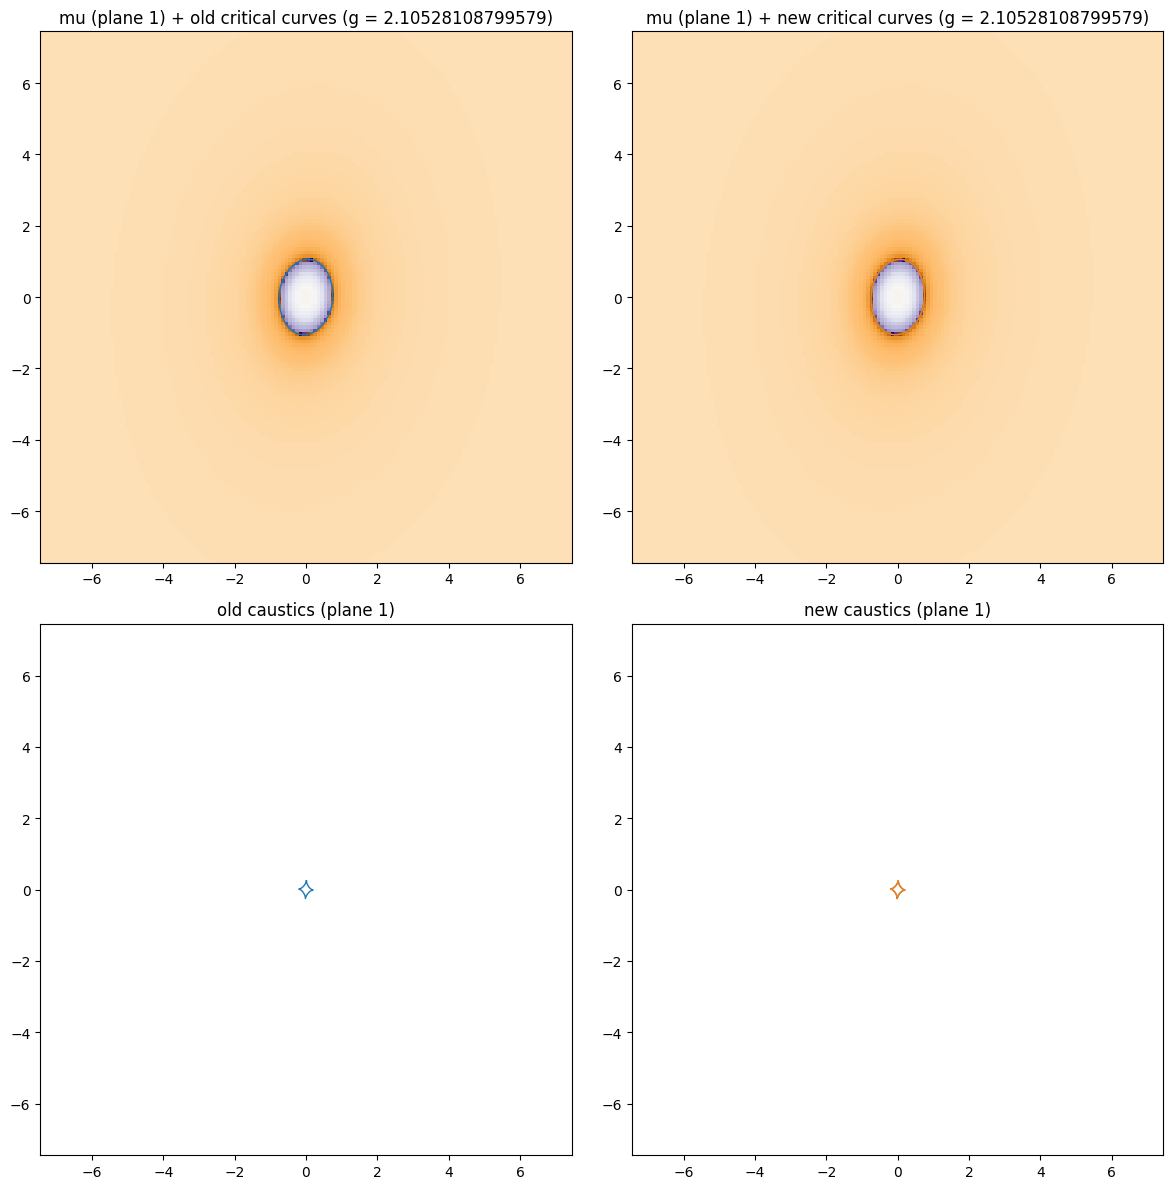

In [164]:
# ...existing code...
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

# 1) magnification (plane 1) + old critical curves
ax = axs[0, 0]
im = ax.imshow(mu_wrts1, origin='lower', cmap='PuOr_r', extent=dspl.pixel_grid.extent, norm="symlog")
# fig.colorbar(im, ax=ax)
ax.set_title(f'mu (plane 1) + old critical curves (g = {gamma})')
for i, c in enumerate(cc_wrts1_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 2) magnification (plane 1) + new critical curves
ax = axs[0, 1]
im = ax.imshow(mu_wrts1, origin='lower', cmap='PuOr_r', extent=dspl.pixel_grid.extent, norm="symlog")
# fig.colorbar(im, ax=ax)
ax.set_title(f'mu (plane 1) + new critical curves (g = {gamma})')
for i, c in enumerate(cc_wrts1_new):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 3) old caustics (plane 1)
ax = axs[1, 0]
ax.set_title('old caustics (plane 1)')
for i, c in enumerate(caustic_wrts1_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

# 4) new caustics (plane 1)
ax = axs[1, 1]
ax.set_title('new caustics (plane 1)')
for i in range(caustics_wrts1_x.shape[0]):
    ax.plot(caustics_wrts1_x[i], caustics_wrts1_y[i], color=f'C{i%10}', lw=1)
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig("figures_out/sspl_caustics_eg9.png")
plt.show()
# ...existing code...

In [ ]:
# ...existing code...
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

xmin, xmax, ymin, ymax = dspl.pixel_grid.extent

# 1) magnification (plane 2) + old critical curves
ax = axs[0, 0]
im = ax.imshow(mu_wrts2, origin='lower', cmap='PuOr_r', norm="symlog", extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 2) + old critical curves')
for i, c in enumerate(cc_wrts2_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 2) magnification (plane 2) + new critical curves
ax = axs[0, 1]
im = ax.imshow(mu_wrts2, origin='lower', cmap='PuOr_r', norm="symlog", extent=dspl.pixel_grid.extent)
# fig.colorbar(im, ax=ax)
ax.set_title('mu (plane 2) + new critical curves')
for i, c in enumerate(cc_wrts2_new):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 3) old caustics (plane 2)
ax = axs[1, 0]
ax.set_title('old caustics (plane 2)')
for i, c in enumerate(caustic_wrts2_old):
    ax.plot(c[:, 0], c[:, 1], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

# 4) new caustics (plane 2)
ax = axs[1, 1]
ax.set_title('new caustics (plane 2)')
for i in range(caustics_wrts2_x.shape[0]):
    ax.plot(caustics_wrts2_x[i], caustics_wrts2_y[i], color=f'C{i%10}', lw=1, label=i)
# ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.legend()

plt.tight_layout()
# plt.savefig("figures_out/caustics_polar_example2.png")
plt.show()

In [166]:
%matplotlib inline
import matplotlib.pyplot as plt

In [167]:
print(caustics_wrts1_x[1])

[-0.10468602 -0.104958   -0.10523021 ...         nan         nan
         nan]


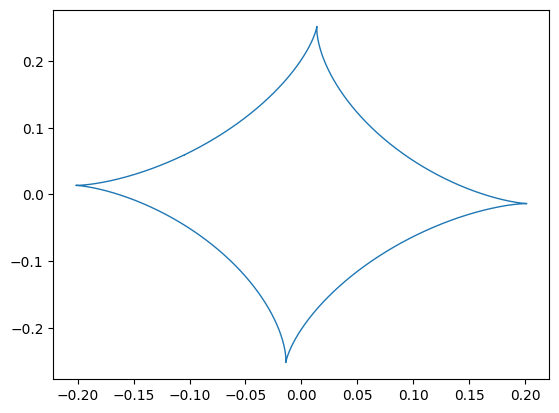

In [168]:
i=1
clean_x = caustics_wrts1_x[i][jnp.isfinite(caustics_wrts1_x[i])]
clean_y = caustics_wrts1_y[i][jnp.isfinite(caustics_wrts1_y[i])]
plt.plot(clean_x, clean_y, lw=1)
plt.show()

In [169]:
plt.close()